# **3. Spectograms**

The function `parse_dataset_spectrogram()` transforms raw audio files into structured time–frequency representations using the Short-Time Fourier Transform (STFT).

Instead of computing a single FFT for the entire signal (global frequency content), we compute multiple FFTs over small time windows. This produces a **spectrogram**, which preserves both time and frequency information.

we obtain:

* A 2D matrix where:
  - The **x-axis** represents time
  - The **y-axis** represents frequency
  - Each cell represents the energy (magnitude) of a frequency at a specific time





### LIBRARIES

In [1]:
print("Spectogram")

Spectogram


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import os
import IPython.display as ipd
import librosa
import soundfile as sf
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import json
from datetime import datetime

### Data Paths

In [3]:
output_segmented_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats"
output_segmented_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs"

## **1. Data Preprocessing**

In [4]:
def parse_dataset_spectrogram(dataset_paths):
    X = []
    y = []

    for index, dataset in enumerate(dataset_paths):
        print(f"[+] Parsing {dataset} data...")

        for fname in os.listdir(dataset):
            wav, sr = librosa.load(os.path.join(dataset, fname), sr=None)
            stft = librosa.stft(wav, n_fft=1024, hop_length=512)

            spectrogram = np.abs(stft)
            spectrogram_db = librosa.amplitude_to_db(spectrogram)

            X.append(spectrogram_db)
            y.append(index)

    return X, y



dataset_paths = [output_segmented_cats_path, output_segmented_dogs_path]
X, y = parse_dataset_spectrogram(dataset_paths)

[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats data...


c:\Users\Ale\Documents\Lab01\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs data...


In [5]:
print(y)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [6]:
print("The length of the data set is: ", len(X))

The length of the data set is:  580


#### We divide the dataset into training and testing.

In [7]:
print(np.array(X).shape)


(580, 513, 130)


In [8]:
X_array = np.array(X)

X_prep = X_array.reshape(X_array.shape[0], -1)
X_prep = X_prep.astype('float32')

y_prep = np.array(y).astype('float32')

print(X_prep.shape)

(580, 66690)


In [9]:
y_prep = np.array(y).astype('float32')

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_prep, y_prep, test_size=0.15, random_state=42)

In [11]:
print("Length of training subset: ", len(X_train))
print("Lenght of testing subset: ", len(X_test))

Length of training subset:  493
Lenght of testing subset:  87


Text(0.5, 1.0, 'Distribution of classes in the training set')

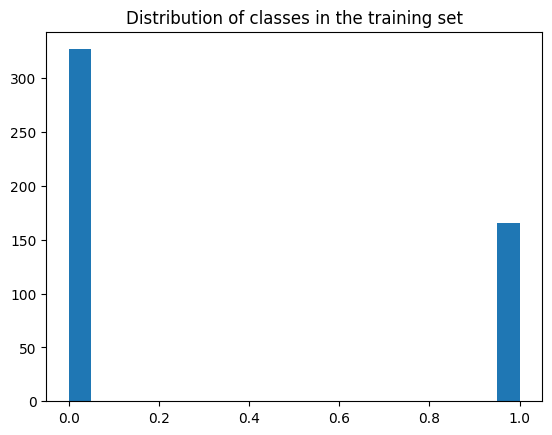

In [12]:
plt.hist(y_train, bins=20)
plt.title("Distribution of classes in the training set")

### **1. Model Construction**

In [28]:
network = models.Sequential()

network.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
network.add(layers.Dense(32, activation='relu'))
network.add(layers.Dense(1, activation='sigmoid'))

network.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', 'Precision'])


history = network.fit(X_train, 
                      y_train,
                      batch_size=32,
                      epochs=15, 
                      validation_data=(X_test, y_test))

Epoch 1/15
16/16 [==============================] - 1s 36ms/step - loss: 232.4452 - accuracy: 0.5680 - precision: 0.3626 - val_loss: 110.8864 - val_accuracy: 0.6782 - val_precision: 0.0000e+00
Epoch 2/15
16/16 [==============================] - 0s 25ms/step - loss: 71.7758 - accuracy: 0.6917 - precision: 0.5380 - val_loss: 59.4248 - val_accuracy: 0.7816 - val_precision: 1.0000
Epoch 3/15
16/16 [==============================] - 0s 22ms/step - loss: 27.1337 - accuracy: 0.8296 - precision: 0.7412 - val_loss: 29.8114 - val_accuracy: 0.7816 - val_precision: 0.6364
Epoch 4/15
16/16 [==============================] - 0s 22ms/step - loss: 23.0796 - accuracy: 0.8316 - precision: 0.7515 - val_loss: 60.1301 - val_accuracy: 0.7586 - val_precision: 1.0000
Epoch 5/15
16/16 [==============================] - 0s 21ms/step - loss: 32.1862 - accuracy: 0.7769 - precision: 0.6750 - val_loss: 32.0318 - val_accuracy: 0.7011 - val_precision: 0.5227
Epoch 6/15
16/16 [==============================] - 0s 22ms

In [29]:
y_pred_probs = network.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

3/3 [==============================] - 0s 5ms/step


In [30]:
y_test = np.array(y_test).flatten()

### **RESULTS**

In [31]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8620689655172413
Precision: 1.0
Recall: 0.5714285714285714
F1 Score: 0.7272727272727273
AUC: 0.78571427

Confusion Matrix:
[[59  0]
 [12 16]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        59
         1.0       1.00      0.57      0.73        28

    accuracy                           0.86        87
   macro avg       0.92      0.79      0.82        87
weighted avg       0.89      0.86      0.85        87



In [32]:
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy()

display(HTML(f"""
<div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
</div>
"""))


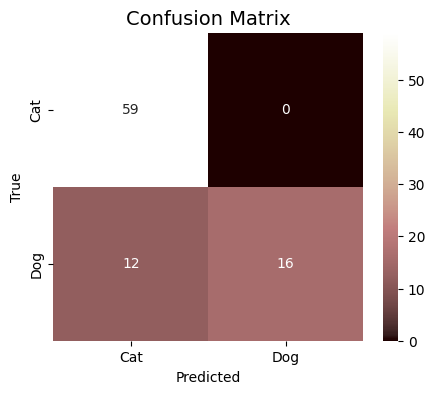

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [34]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient(cmap="RdPu")

,precision,recall,f1-score,support
0.0,0.830986,1.000000,0.907692,59.000000
1.0,1.000000,0.571429,0.727273,28.000000
accuracy,0.862069,0.862069,0.862069,0.862069
macro avg,0.915493,0.785714,0.817483,87.000000
weighted avg,0.885381,0.862069,0.849626,87.000000


In [35]:
model_name = "3. MLP"
representation = "Spectogram"
save_dir_path = "model_metrics"

metrics_dict = {"model": model_name,
        "representation": representation,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

if not os.path.exists(save_dir_path):
    os.makedirs(save_dir_path, exist_ok=True)

file_path = os.path.join(save_dir_path, f"{model_name}_{representation}.json")

with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
print(f"Metrics saved to: {file_path}")

Metrics saved to: model_metrics\3. MLP_Spectogram.json
